In [2]:
import numpy as np
from matplotlib import pyplot as plt
import deepxde as dde
dde.backend.set_default_backend("pytorch")
from scipy.io import loadmat
import re

C1true = 1.0
C2true = 0.01

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [3]:
# load the training data

def load_training_data (num):
    data = loadmat("cylinder_nektar_wake.mat")
    #print(data)
    
    U_star = data["U_star"] #N X 2 X T
    P_star = data["p_star"] #N X T
    t_star = data["t"]  # T
    X_star = data["X_star"] # N X 2
    
    #print("X_star.shape",X_star.shape)
    #print("X_star",X_star)
    
    N = X_star.shape[0]
    T = t_star.shape[0]
    
    XX = np.tile(X_star[:,0:1], (1,T))
    YY = np.tile(X_star[:,1:2], (1,T))
    TT = np.tile(t_star, (1,N)).T
    UU = U_star[:, 0, :]
    VV = U_star[:, 1, :]
    PP = P_star
    
    #print("VVshape",VV.shape)
    #print("VV",VV)
    
    x = XX.flatten().unsqueeze(1)  # N*T x 1
    y = YY.flatten().unsqueeze(1)
    t = TT.flatten().unsqueeze(1)
    u = UU.flatten().unsqueeze(1)
    v = VV.flatten().unsqueeze(1)
    p = PP.flatten().unsqueeze(1)
    
    #print("t.shape",t.shape)
    #print("t",t)
    
    data1 = np.concatenate([x, y, t, u, v, p], 1)
    
    #print("data1.shape",data1.shape)
    #print("data1",data1)
    
    # X xY = [1,8] x [-2, 2],  time = [0,7]
    
    data2 = data1[:,:][data1[:,2] <= 7]
    data3 = data2[:,:][data2[:,0] >= 1]
    data4 = data3[:,:][data3[:,0] <= 8]
    data5 = data4[:,:][data4[:,1] >= -2]
    data6 = data5[:,:][data5[:,1] <= 2]
    
    data_domian = data6
    
    #print("data_domian.shape",data_domian.shape)
    #print("data_domian",data_domian)
    
    idx = np.random.choice(data_domian.shape[0], num, replace= False)
    
    #print("idx",idx)
    
    x_train = data_domian[idx, 0:1]
    y_train = data_domian[idx, 1:2]
    t_train = data_domian[idx, 2:3]
    u_train = data_domian[idx, 3:4]
    v_train = data_domian[idx, 4:5]
    p_train = data_domian[idx, 5:6]
    
    return [x_train, y_train, t_train, u_train, v_train, p_train]

	•	1 <= x <= 8
	•	-2 <= y <= 2
	•	t <= 7


In [ ]:
import torch
from scipy.io import loadmat

def load_training_data(num, device="cpu"):
    data = loadmat("cylinder_nektar_wake.mat")

    X = torch.tensor(data["X_star"], dtype=torch.float32)
    t = torch.tensor(data["t"].flatten(), dtype=torch.float32)
    U = torch.tensor(data["U_star"], dtype=torch.float32)
    P = torch.tensor(data["p_star"], dtype=torch.float32)

    N, T = X.shape[0], t.shape[0]

    x = X[:, 0:1].repeat(1, T)
    y = X[:, 1:2].repeat(1, T)
    tt = t[None, :].repeat(N, 1)

    u = U[:, 0, :]
    v = U[:, 1, :]
    p = P

    data_all = torch.column_stack([
        x.flatten(),
        y.flatten(),
        tt.flatten(),
        u.flatten(),
        v.flatten(),
        p.flatten()
    ])

    mask = (
        (data_all[:, 2] <= 7) &
        (data_all[:, 0] >= 1) & (data_all[:, 0] <= 8) &
        (data_all[:, 1] >= -2) & (data_all[:, 1] <= 2)
    )

    data_domain = data_all[mask]

    idx = torch.randperm(data_domain.shape[0])[:num]
    data_sampled = data_domain[idx].to(device)

    return (
        data_sampled[:, 0:1],
        data_sampled[:, 1:2],
        data_sampled[:, 2:3],
        data_sampled[:, 3:4],
        data_sampled[:, 4:5],
        data_sampled[:, 5:6],
    )

	•	1 <= x <= 8
	•	-2 <= y <= 2
	•	t <= 7

In [4]:
[ob_x, ob_y, ob_t, ob_u, ob_v, ob_p] = load_training_data(num = 7000)

print("ob_y.shape",ob_y.shape)
print("ob_y",ob_y)

ob_xyt = np.hstack((ob_x,ob_y,ob_t))


print("ob_xyt.shape",ob_xyt.shape)
print("ob_xyt",ob_xyt)

ob_y.shape (7000, 1)
ob_y [[ 1.51020408]
 [ 1.51020408]
 [-0.7755102 ]
 ...
 [-1.67346939]
 [ 0.93877551]
 [ 1.91836735]]
ob_xyt.shape (7000, 3)
ob_xyt [[ 1.35353535  1.51020408  3.7       ]
 [ 7.15151515  1.51020408  6.4       ]
 [ 6.16161616 -0.7755102   6.7       ]
 ...
 [ 6.44444444 -1.67346939  3.5       ]
 [ 3.33333333  0.93877551  2.1       ]
 [ 6.7979798   1.91836735  0.4       ]]


In [5]:
C1 = dde.Variable(0.0)
C2 = dde.Variable(0.0)

In [6]:
def Navier_Stokes_Equation(x,y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    p = y[:, 2:3]
    
    
    du_x = dde.grad.jacobian(y, x, i=0, j=0)
    du_y = dde.grad.jacobian(y, x, i=0, j=1)
    du_t = dde.grad.jacobian(y, x, i=0, j=2)
    
    dv_x = dde.grad.jacobian(y, x, i=1, j=0)
    dv_y = dde.grad.jacobian(y, x, i=1, j=1)
    dv_t = dde.grad.jacobian(y, x, i=1, j=2)
    
    dp_x = dde.grad.jacobian(y, x, i=2, j=0)
    dp_y = dde.grad.jacobian(y, x, i=2, j=1)
    
    du_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(y, x, component=0, i=1, j=1)
    
    dv_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(y, x, component=1, i=1, j=1)
    
    continuity = du_x + dv_y
    x_momentum = du_t + C1 * (u * du_x + v * du_y) + dp_x - C2 * (du_xx + du_yy)
    y_momentum = dv_t + C1 * (u * dv_x + v * dv_y) + dp_y - C2 * (dv_xx + dv_yy)
    
    return [continuity, x_momentum, y_momentum]

In [7]:
# define the DNN
layer_size = [3] + [50]*6 + [3]
activation = "tanh"
intializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, intializer)

In [8]:
Lx_min, Lx_max = 1.0, 8.0
Ly_min, Ly_max = -2.0, 2.0

space_domain = dde.geometry.Rectangle([Lx_min,Ly_min],[Lx_max,Ly_max])

time_domain =dde.geometry.TimeDomain(0,7)

geomtime =dde.geometry.GeometryXTime(space_domain,time_domain)

In [9]:
obsevrve_u = dde.icbc.PointSetBC(ob_xyt,ob_u, component=0)
obsevrve_v = dde.icbc.PointSetBC(ob_xyt,ob_v, component=1)
obsevrve_p = dde.icbc.PointSetBC(ob_xyt,ob_p, component=2)

In [10]:
# Training dataset used to calculate the loss
data = dde.data.TimePDE(geomtime,
                        Navier_Stokes_Equation,
                        [obsevrve_u, obsevrve_v, obsevrve_p],
                       num_domain = 700,
                       num_boundary=200,
                       num_initial=100,
                       anchors= ob_xyt)

Compiling model...
'compile' took 0.000762 s

Training model...

0         [8.39e-04, 1.63e-03, 4.95e-03, 2.10e-02, 4.48e-02, 5.48e-03]    [8.39e-04, 1.63e-03, 4.95e-03, 2.10e-02, 4.48e-02, 5.48e-03]    []  
100       [1.05e-03, 2.20e-03, 7.62e-03, 1.80e-02, 3.35e-02, 5.03e-03]    [1.05e-03, 2.20e-03, 7.62e-03, 1.80e-02, 3.35e-02, 5.03e-03]    []  
200       [9.36e-04, 2.75e-03, 7.45e-03, 1.40e-02, 2.70e-02, 4.29e-03]    [9.36e-04, 2.75e-03, 7.45e-03, 1.40e-02, 2.70e-02, 4.29e-03]    []  
300       [7.99e-04, 2.82e-03, 6.15e-03, 1.11e-02, 2.27e-02, 3.45e-03]    [7.99e-04, 2.82e-03, 6.15e-03, 1.11e-02, 2.27e-02, 3.45e-03]    []  
400       [1.02e-03, 2.74e-03, 4.66e-03, 8.63e-03, 2.25e-02, 2.83e-03]    [1.02e-03, 2.74e-03, 4.66e-03, 8.63e-03, 2.25e-02, 2.83e-03]    []  
500       [8.48e-04, 2.20e-03, 4.01e-03, 6.67e-03, 1.42e-02, 2.15e-03]    [8.48e-04, 2.20e-03, 4.01e-03, 6.67e-03, 1.42e-02, 2.15e-03]    []  
600       [8.12e-04, 1.81e-03, 2.88e-03, 5.02e-03, 9.60e-03, 1.62e-03]    [8.

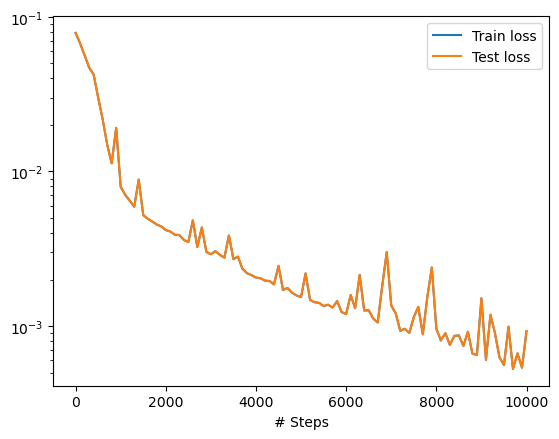

Compiling model...
'compile' took 0.000557 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
10000     [1.57e-04, 1.40e-04, 1.34e-04, 2.32e-04, 2.33e-04, 3.15e-05]    [1.57e-04, 1.40e-04, 1.34e-04, 2.32e-04, 2.33e-04, 3.15e-05]    []  
10100     [6.20e-05, 9.54e-05, 7.86e-05, 1.11e-04, 1.24e-04, 1.58e-05]    [6.20e-05, 9.54e-05, 7.86e-05, 1.11e-04, 1.24e-04, 1.58e-05]    []  
10200     [6.17e-05, 9.48e-05, 7.79e-05, 1.10e-04, 1.22e-04, 1.56e-05]    [6.17e-05, 9.48e-05, 7.79e-05, 1.10e-04, 1.22e-04, 1.56e-05]    []  
10300     [6.11e-05, 9.39e-05, 7.71e-05, 1.08e-04, 1.20e-04, 1.54e-05]    [6.11e-05, 9.39e-05, 7.71e-05, 1.08e-04, 1.20e-04, 1.54e-05]    []  
10400     [6.05e-05, 9.27e-05, 7.63e-05, 1.06e-04, 1.17e-04, 1.51e-05]    [6.05e-05, 9.27e-05, 7.63e-05, 1.06e-04, 1.17e-04, 1.51e-05]    []  
10500     [5.96e-05, 9.16e-05, 7.54e-05, 1.05e-04, 1.15e-04, 1.49e-05]

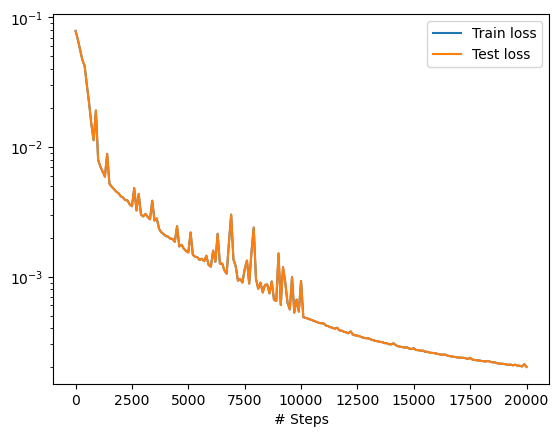

Mean residual: 0.0041544


In [12]:
model = dde.Model(data, net)

results_file_C1_C2 = "variables_main_C1_C2.dat"
variable = dde.callbacks.VariableValue([C1,C2], period = 100, filename= results_file_C1_C2)

model.compile("adam", lr=1e-3, external_trainable_variables=[C1,C2])
loss_history, train_state= model.train(iterations=10000, callbacks=[variable],display_every=100,disregard_previous_best= True)
dde.saveplot(loss_history, train_state, issave=True, isplot=True)


model.compile("adam", lr=1e-4, external_trainable_variables=[C1,C2])
loss_history, train_state= model.train(iterations=10000, callbacks=[variable],display_every=100,disregard_previous_best= True)
dde.saveplot(loss_history, train_state, issave=True, isplot=True)


f= model.predict(ob_xyt, operator= Navier_Stokes_Equation)
print("Mean residual:", np.mean(np.absolute(f)))

In [2]:
# Plot Variables:
# reopen saved data using callbacks in results_file_C1_C2

results_file_C1_C2 = "variables_main_C1_C2.dat"
lines = open(results_file_C1_C2, "r").readlines()
# read output data in fnamevar
Chat = np.array(
    [
        np.fromstring(
            min(re.findall(re.escape("[") + "(.*?)" + re.escape("]"), line), key=len),
            sep=",",
        )
        for line in lines
    ]
)
l, c = Chat.shape
plt.semilogy(range(0, l * 100, 100), Chat[:, 0], "r-")
plt.semilogy(range(0, l * 100, 100), Chat[:, 1], "k-")
plt.semilogy(range(0, l * 100, 100), np.ones(Chat[:, 0].shape) * C1true, "r--")
plt.semilogy(range(0, l * 100, 100), np.ones(Chat[:, 1].shape) * C2true, "k--")
plt.legend(["C1hat", "C2hat", "True C1", "True C2"], loc="right")
plt.xlabel("Epochs")
plt.title("Variables")
plt.show()

NameError: name 're' is not defined

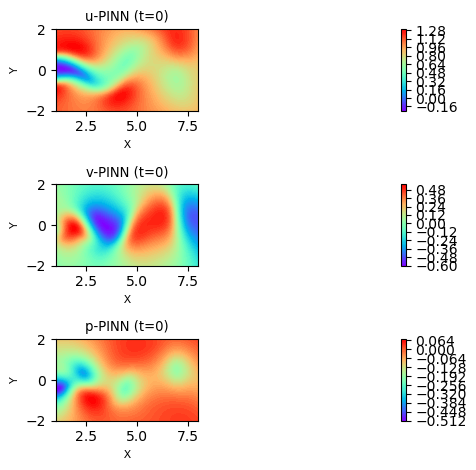

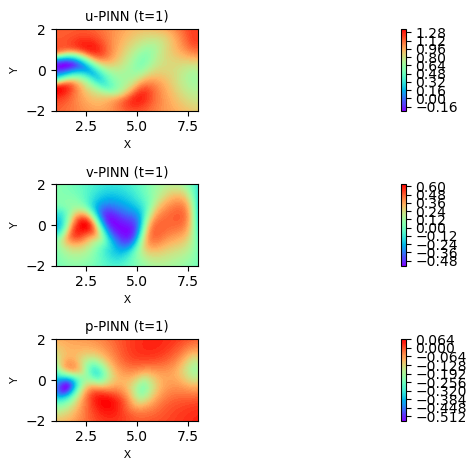

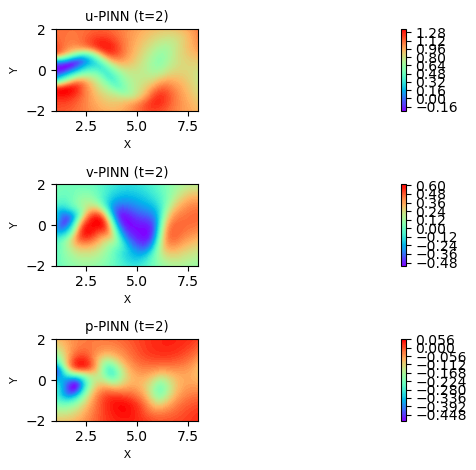

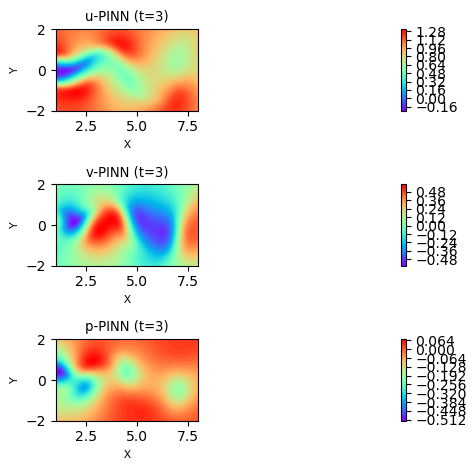

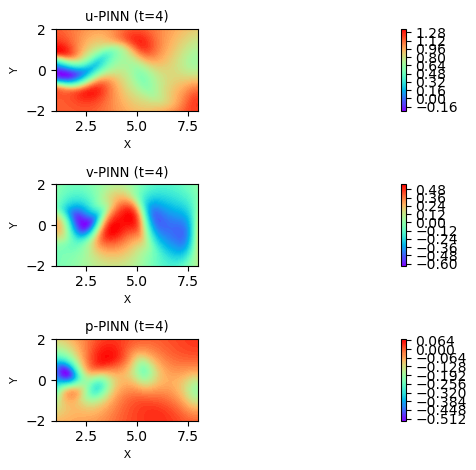

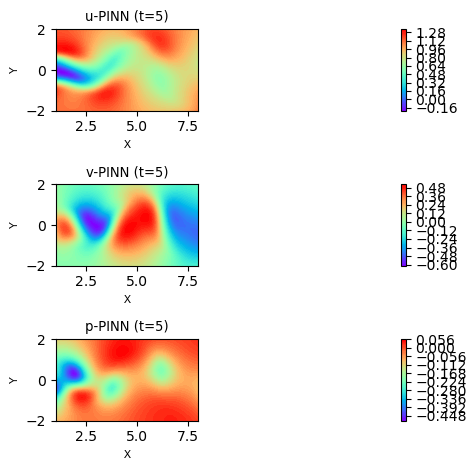

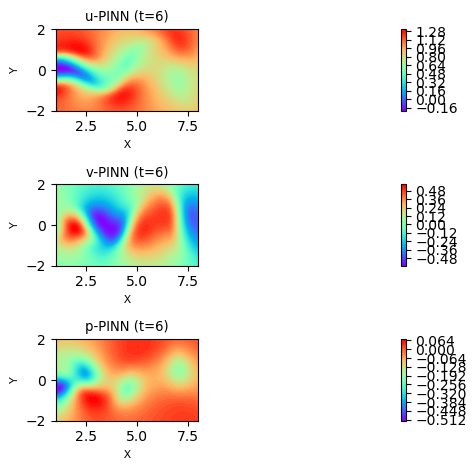

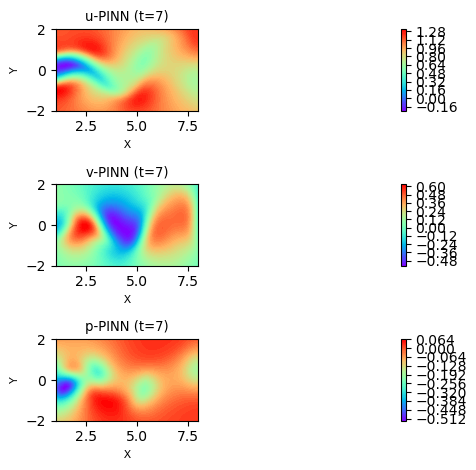

In [14]:
# Plot the velocity and pressure distribution of the flow field:
for t in range(0, 8):
    [ob_x, ob_y, ob_t, ob_u, ob_v, ob_p] = load_training_data(num=140000)
    xyt_pred = np.hstack((ob_x, ob_y, t * np.ones((len(ob_x), 1))))
    uvp_pred = model.predict(xyt_pred)
    x_pred, y_pred, t_pred = xyt_pred[:, 0], xyt_pred[:, 1], xyt_pred[:, 2]
    u_pred, v_pred, p_pred = uvp_pred[:, 0], uvp_pred[:, 1], uvp_pred[:, 2]
    x_true = ob_x[ob_t == t]
    y_true = ob_y[ob_t == t]
    u_true = ob_u[ob_t == t]
    p_true = ob_p[ob_t == t]  # Extract pressure values
    fig, ax = plt.subplots(3, 1)  # Create three subplots
    # Velocity subplot
    cntr0 = ax[0].tricontourf(x_pred, y_pred, u_pred, levels=80, cmap="rainbow")
    cb0 = plt.colorbar(cntr0, ax=ax[0])
    cntr1 = ax[1].tricontourf(x_pred, y_pred, v_pred, levels=80, cmap="rainbow")
    cb1 = plt.colorbar(cntr1, ax=ax[1])
    # Pressure subplot
    cntr2 = ax[2].tricontourf(x_pred, y_pred, p_pred, levels=80, cmap="rainbow")
    cb2 = plt.colorbar(cntr2, ax=ax[2])
    ax[0].set_title("u-PINN " + "(t=" + str(t) + ")", fontsize=9.5)
    ax[1].set_title("v-PINN " + "(t=" + str(t) + ")", fontsize=9.5)
    ax[2].set_title("p-PINN " + "(t=" + str(t) + ")", fontsize=9.5)  # Title for pressure subplot
    for i in range(3):
        ax[i].axis("scaled")
        ax[i].set_xlabel("X", fontsize=7.5, family="Arial")
        ax[i].set_ylabel("Y", fontsize=7.5, family="Arial")
    fig.tight_layout()
    plt.show()